Thí nghiệm 1: Quan sát phản ứng với sóng hình Sin


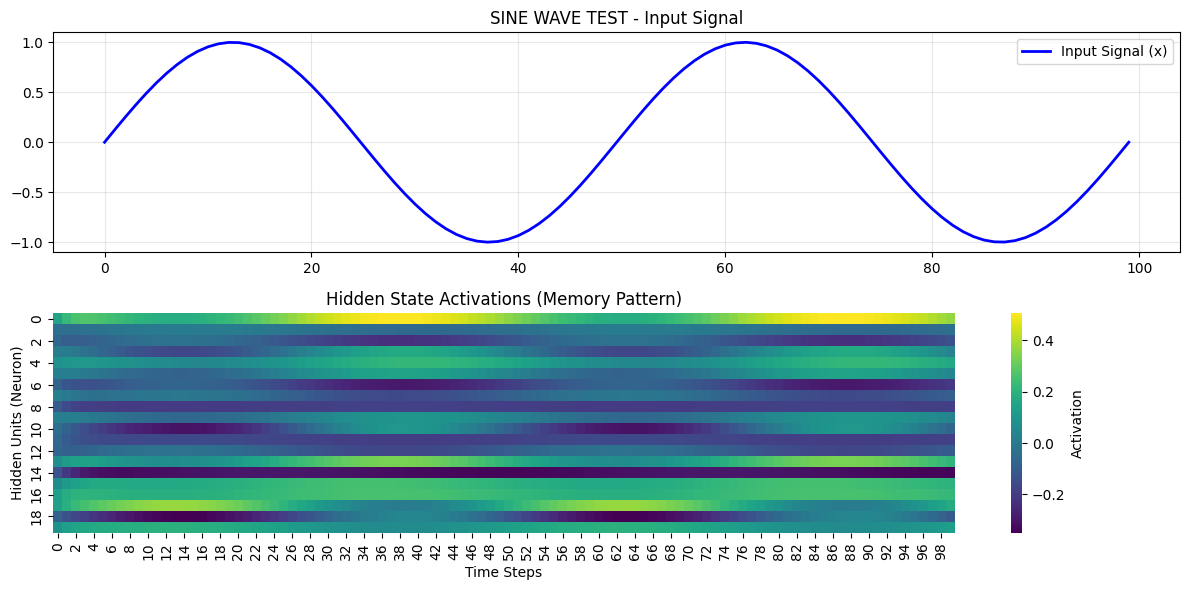


Thí nghiệm 2: Quan sát trí nhớ (Impulse Response)


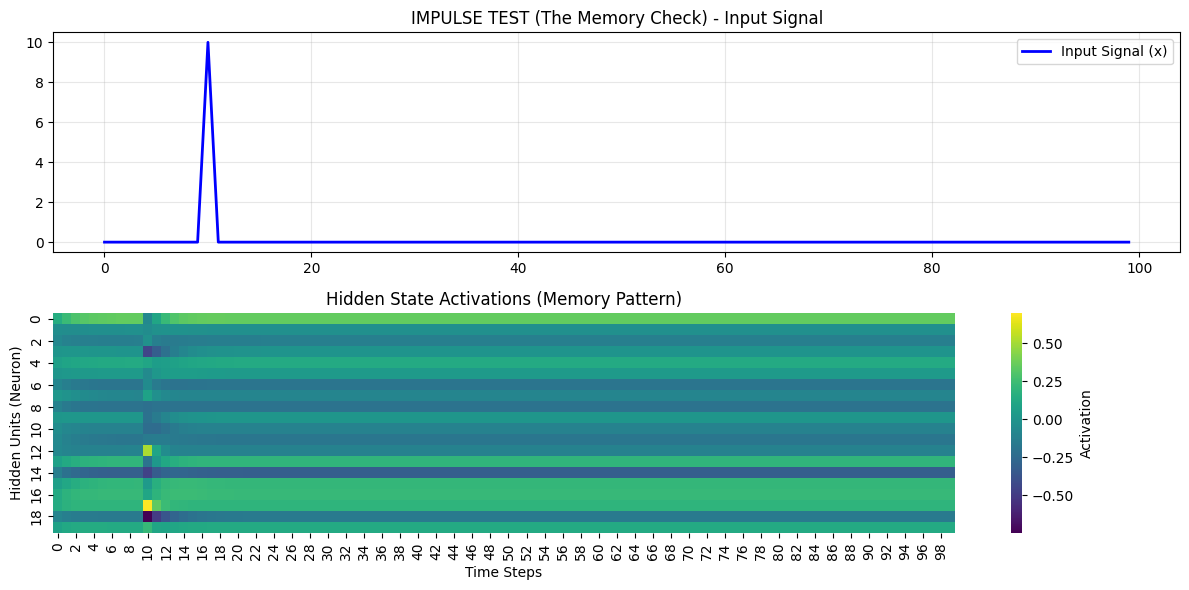

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gru import GRU  # Import file gru.py bạn vừa viết

def plot_activity(inputs, hidden_states, title):
    """
    Vẽ Input và Hoạt động của Hidden State
    """
    plt.figure(figsize=(12, 6))
    
    # 1. Vẽ Input (Dữ liệu vào)
    plt.subplot(2, 1, 1)
    plt.plot(inputs[0, :, 0].numpy(), label='Input Signal (x)', color='blue', linewidth=2)
    plt.title(f"{title} - Input Signal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 2. Vẽ Hidden State (Bản đồ nhiệt ký ức)
    # Đây là cách nhìn vào "bộ não" của GRU
    plt.subplot(2, 1, 2)
    # Chuyển hidden state về numpy và transpose để vẽ heatmap (Feature x Time)
    h_map = hidden_states[0, :, 0, :].detach().numpy().T 
    sns.heatmap(h_map, cmap='viridis', cbar_kws={'label': 'Activation'})
    plt.title("Hidden State Activations (Memory Pattern)")
    plt.xlabel("Time Steps")
    plt.ylabel("Hidden Units (Neuron)")
    
    plt.tight_layout()
    plt.show()

# --- BẮT ĐẦU THÍ NGHIỆM ---

# Cấu hình Model
input_size = 1
hidden_size = 20 # Giả sử bộ não có 20 nơ-ron ký ức
seq_len = 100    # Quan sát trong 100 bước thời gian
model = GRU(input_size, hidden_size, num_layers=1, batch_first=True)

# THÍ NGHIỆM 1: SÓNG HÌNH SIN (Continuous Wave)
# Tạo sóng sin làm input
t = np.linspace(0, 4*np.pi, seq_len)
wave = np.sin(t)
x_sin = torch.FloatTensor(wave).view(1, seq_len, 1, 1) # (Batch, Seq, Nodes, Feat)

# Chạy model
output_sin, hidden_sin = model(x_sin)

print("Thí nghiệm 1: Quan sát phản ứng với sóng hình Sin")
plot_activity(x_sin, output_sin, "SINE WAVE TEST")


# THÍ NGHIỆM 2: XUNG KÍCH (Impulse Response)
# Input = 0 hết, chỉ có tại thời điểm t=10 là nhảy lên 10 rồi lại về 0
x_impulse = torch.zeros(1, seq_len, 1, 1)
x_impulse[0, 10, 0, 0] = 10.0 # Cú sốc tại t=10

# Chạy model
output_imp, hidden_imp = model(x_impulse)

print("\nThí nghiệm 2: Quan sát trí nhớ (Impulse Response)")
plot_activity(x_impulse, output_imp, "IMPULSE TEST (The Memory Check)")